# MiniLM Benchmark - Symptoms Disease Classification

In [80]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer, DataCollatorWithPadding, pipeline
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight

device = "cuda" if torch.cuda.is_available() else "cpu"

## Load Dataset

In [81]:
ds = load_dataset("ninaa510/diagnosis-text")

train_ds = ds["train"].rename_column("sentence1", "text").class_encode_column("label")
test_ds = ds["test"].rename_column("sentence1", "text").class_encode_column("label")

train_ds

Dataset({
    features: ['label', 'text'],
    num_rows: 13310
})

In [82]:
train_ds[0]

{'label': 0,
 'text': 'I am a 12-year-old male with an itchy nose, sharp upper abdominal pain, pink skin lesions or rashes on my neck, swelling in my nose, had an allergic reaction, and experiencing high-pitched breathing sounds, lightheadedness, and wheezing on exhale.'}

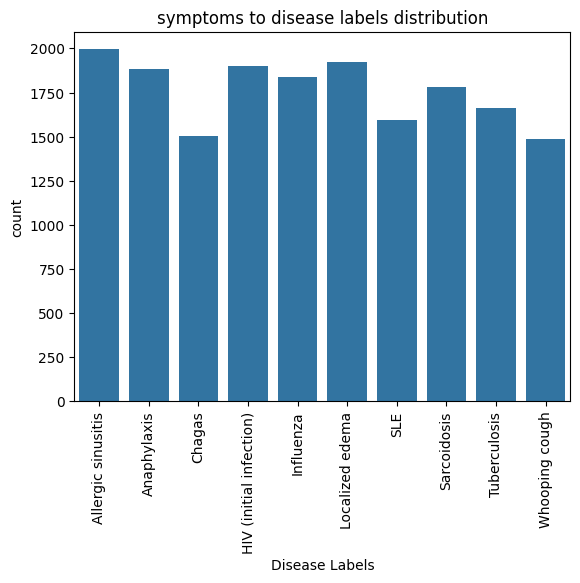

In [83]:
train = pd.DataFrame(ds["train"])
test = pd.DataFrame(ds["test"])

df = pd.concat([train, test], ignore_index=True)

sns.countplot(data=df, x="label")
plt.title("symptoms to disease labels distribution")
plt.xlabel("Disease Labels")
plt.xticks(rotation=90)
plt.ylabel("count")
plt.show()

In [84]:
total_labels = len(set(train_ds["label"]))
print(f"Total number of labels: {total_labels}")

Total number of labels: 10


## Load MiniLM Model

In [85]:
mini_lm = "microsoft/MiniLM-L12-H384-uncased"

mini_lm_tokenizer = AutoTokenizer.from_pretrained(mini_lm)

mini_lm_model = AutoModelForSequenceClassification.from_pretrained(
    mini_lm,
    num_labels=total_labels,
)

mini_lm_model.to(device)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 1486.26it/s, Materializing param=bert.pooler.dense.weight]                               
BertForSequenceClassification LOAD REPORT from: microsoft/MiniLM-L12-H384-uncased
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 384, padding_idx=0)
      (position_embeddings): Embedding(512, 384)
      (token_type_embeddings): Embedding(2, 384)
      (LayerNorm): LayerNorm((384,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=384, out_features=384, bias=True)
              (key): Linear(in_features=384, out_features=384, bias=True)
              (value): Linear(in_features=384, out_features=384, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=384, out_features=384, bias=True)
              (LayerNorm): LayerNorm((384,), eps=1e-12,

In [86]:
# Total number of parameters
mini_lm_params = sum(p.numel() for p in mini_lm_model.parameters() if p.requires_grad)
print(f"MiniLM parameters: {mini_lm_params:,}")

MiniLM parameters: 33,363,850


## Tokenizing Dataset

In [87]:
def tokenize(batch):
    return mini_lm_tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=256
    )

tokenized_train = train_ds.map(tokenize, batched=True, batch_size=1024)
tokenized_test = test_ds.map(tokenize, batched=True, batch_size=1024)

Map: 100%|██████████| 4262/4262 [00:00<00:00, 14320.75 examples/s]


In [88]:
tokenized_train, tokenized_test

(Dataset({
     features: ['label', 'text', 'input_ids', 'token_type_ids', 'attention_mask'],
     num_rows: 13310
 }),
 Dataset({
     features: ['label', 'text', 'input_ids', 'token_type_ids', 'attention_mask'],
     num_rows: 4262
 }))

In [89]:
# remove the raw text column, we dont want a string
tokenized_train = tokenized_train.remove_columns(["text"])
tokenized_test = tokenized_test.remove_columns(["text"])

tokenized_train.set_format("torch")
tokenized_test.set_format("torch")

In [90]:
tokenized_train

Dataset({
    features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 13310
})

## Model Training (Fine Tuning)

In [91]:
def compute_metrics(pred):
    logits, labels = pred
    preds = logits.argmax(axis=-1)

    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds, average="weighted")

    return {"accuracy": acc, "f1": f1}

In [92]:
LR = 2e-5
BATCH_SIZE = 16
NUM_EPOCH = 3

output_path = "./results/mini_lm"

training_args = TrainingArguments(
    output_dir=output_path,
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=LR,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    num_train_epochs=NUM_EPOCH,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
)

In [93]:
data_collator = DataCollatorWithPadding(mini_lm_tokenizer)

In [94]:
trainer = Trainer(
    model=mini_lm_model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

In [95]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,1.994110,1.386953,0.549977,0.528723
2,1.256033,1.179432,0.569686,0.543888
3,1.174298,1.139835,0.571797,0.542949


Writing model shards: 100%|██████████| 1/1 [00:00<00:00, 13.28it/s]
There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer

TrainOutput(global_step=2496, training_loss=1.4016147026648889, metrics={'train_runtime': 239.138, 'train_samples_per_second': 166.975, 'train_steps_per_second': 10.437, 'total_flos': 1315337960724480.0, 'train_loss': 1.4016147026648889, 'epoch': 3.0})

In [96]:
trainer.save_model(output_path)
mini_lm_tokenizer.save_pretrained(output_path)

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  9.43it/s]


('./results/mini_lm\\tokenizer_config.json',
 './results/mini_lm\\tokenizer.json')

## Model Evaluation

In [97]:
eval_results = trainer.evaluate(eval_dataset=tokenized_test)
eval_results

{'eval_loss': 1.139835000038147,
 'eval_accuracy': 0.5717972782731112,
 'eval_f1': 0.5429486167036676,
 'eval_runtime': 7.5091,
 'eval_samples_per_second': 567.582,
 'eval_steps_per_second': 35.557,
 'epoch': 3.0}

In [98]:
pred = trainer.predict(test_dataset=tokenized_test)
pred.predictions, pred.label_ids

(array([[-1.2378356 ,  0.9229923 ,  0.0889375 , ..., -0.7092945 ,
         -0.5788954 , -2.8383932 ],
        [-1.4819034 ,  1.5232066 , -0.59876907, ..., -0.6668163 ,
         -1.4935161 , -0.02568022],
        [ 4.0952764 , -1.7373763 , -1.3765153 , ...,  0.88601667,
          0.34748635,  0.3137423 ],
        ...,
        [ 3.8373725 , -1.9369587 , -1.2203486 , ...,  0.43429932,
          0.7598618 , -0.7104039 ],
        [ 0.7848196 , -1.3004138 , -0.13000761, ..., -0.34788275,
          0.4631234 , -2.49599   ],
        [-2.5478363 ,  2.8994944 ,  0.07187521, ..., -1.5413281 ,
         -0.3124815 , -0.17155837]], shape=(4262, 10), dtype=float32),
 array([6, 5, 0, ..., 4, 4, 1], shape=(4262,)))

In [99]:
pred_labels = np.argmax(pred.predictions, axis=1)
pred_labels

array([6, 5, 0, ..., 0, 4, 1], shape=(4262,))

In [100]:
y_df = pd.DataFrame({
    "predicted": pred_labels,
    "true": pred.label_ids,
})
y_df.head()

,predicted,true
0,6,6
1,5,5
2,0,0
3,4,4
4,5,1


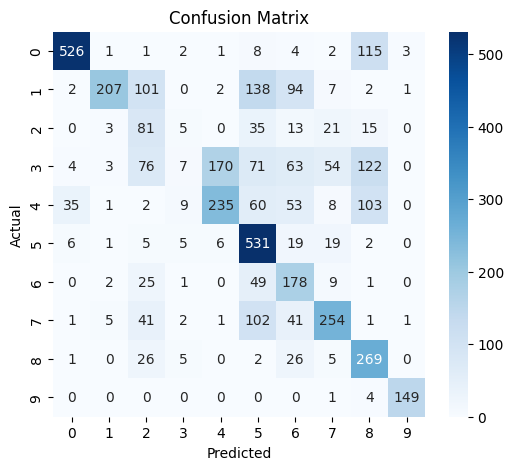

In [101]:
cm = confusion_matrix(pred.label_ids, pred_labels)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [106]:
report = classification_report(pred.label_ids, pred_labels, output_dict=True)
df_report = pd.DataFrame(report).transpose()
df_report.head(9 + 4)

,precision,recall,f1-score,support
0,0.914783,0.793363,0.849758,663.000000
1,0.928251,0.373646,0.532819,554.000000
2,0.226257,0.468208,0.305085,173.000000
3,0.194444,0.012281,0.023102,570.000000
4,0.566265,0.464427,0.510315,506.000000
5,0.533133,0.893939,0.667925,594.000000
6,0.362525,0.671698,0.470899,265.000000
7,0.668421,0.565702,0.612786,449.000000
8,0.424290,0.805389,0.555785,334.000000
9,0.967532,0.967532,0.967532,154.000000


# Inference Example

In [107]:
output_path = "./results/mini_lm"

tokenizer = AutoTokenizer.from_pretrained(output_path)
model = AutoModelForSequenceClassification.from_pretrained(output_path)

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 1147.46it/s, Materializing param=classifier.weight]                                      


In [113]:
model.config.id2label = dict(enumerate(train_ds.features["label"].names))
model.config.label2id = {v:k for k,v in model.config.id2label.items()}

In [118]:
classifier = pipeline("text-classification", model=model, tokenizer=tokenizer)

classifier("i have itchy nose, and i dont feel well")

[{'label': 'Allergic sinusitis', 'score': 0.8439249396324158}]